# 02 — Pipeline de nowcast (construcción de features, modelo, filtro, escalado)

Requiere haber ejecutado `01_diagnostico.ipynb` al menos una vez (carga su configuración desde `../artefactos/`). Este es el notebook que vas a re-ejecutar más a menudo mientras iteras sobre el modelo -- no depende de repetir el diagnóstico completo cada vez.

In [84]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import pickle
import itertools
import time
from utilidades_tep import (
    correlacion_cruzada_maxima, perfil_correlacion_cruzada, MAX_LAG_CUBO,
    construir_features, evaluar_modelo,
    construir_features_multi_sim, evaluar_modelo_split_por_simulacion
)

plt.style.use('ggplot')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## Cargar configuración y datos

Recupera lo decidido en `01_diagnostico.ipynb` -- variable objetivo, listas de variables, señales redundantes -- sin tener que recalcular correlaciones, PACF, ni nada de eso otra vez.

In [85]:
with open('../artefactos/configuracion.pkl', 'rb') as f:
    configuracion = pickle.load(f)

VARIABLE_CALIDAD = configuracion['VARIABLE_CALIDAD']
VARIABLES_XMV = configuracion['VARIABLES_XMV']
VARIABLES_XMEAS = configuracion['VARIABLES_XMEAS']
redundant_pairs = configuracion['redundant_pairs']
RUTA_CSV = configuracion['RUTA_CSV']
COLUMNA_TIEMPO = configuracion['COLUMNA_TIEMPO']

df_recomendacion_features = pd.read_csv('../artefactos/df_recomendacion_features.csv')

df_raw = pd.read_csv(RUTA_CSV)
df_raw = df_raw.sort_values(COLUMNA_TIEMPO).reset_index(drop=True)
df_sim = df_raw[df_raw['simulationRun'] == 1].reset_index(drop=True) if 'simulationRun' in df_raw.columns else df_raw

print("Configuración cargada:")
print("  VARIABLE_CALIDAD:", VARIABLE_CALIDAD)
print("  VARIABLES_XMV:", len(VARIABLES_XMV), "variables")
print("  VARIABLES_XMEAS:", len(VARIABLES_XMEAS), "variables")
print("  Filas df_raw:", len(df_raw), " | df_sim:", len(df_sim))

Configuración cargada:
  VARIABLE_CALIDAD: xmeas_40
  VARIABLES_XMV: 11 variables
  VARIABLES_XMEAS: 40 variables
  Filas df_raw: 250000  | df_sim: 500


## 5. Feature engineering (reutilizamos la función ya construida)

Misma función que en el notebook anterior, con lags + rolling + diff, causales.

In [86]:
def _lags_potencia(n_lags_max, base=2):
    lags = []
    l = 1
    while l < n_lags_max:
        lags.append(l)
        l *= base
    lags.append(n_lags_max)
    return sorted(set(lags))


def construir_features(df, variables_entrada, usar_lags=True, n_lags=3,
                        espaciado_lags='consecutivo', base_potencia=2,
                        usar_rolling_mean=False, ventana_mean=5,
                        usar_rolling_std=False, ventana_std=5,
                        usar_diff=False):
    df_out = df.copy()
    columnas_features = list(variables_entrada)

    if espaciado_lags == 'potencia':
        lista_lags = _lags_potencia(n_lags, base=base_potencia)
    else:
        lista_lags = list(range(1, n_lags + 1))

    # Acumulamos las columnas nuevas en un diccionario y las unimos con UN solo concat al
    # final, en vez de insertarlas una a una con df_out[col] = ... . Insertar columna a
    # columna fragmenta el DataFrame internamente (pandas avisa con PerformanceWarning) y
    # es notablemente más lento cuando esta función se llama muchas veces seguidas -- como
    # ocurre en construir_features_multi_sim, que la invoca una vez POR CADA simulación.
    nuevas_columnas = {}
    for var in variables_entrada:
        if usar_lags:
            for lag in lista_lags:
                col = f'{var}_lag_{lag}'
                nuevas_columnas[col] = df_out[var].shift(lag)
                columnas_features.append(col)
        if usar_rolling_mean:
            col = f'{var}_roll_mean_{ventana_mean}'
            nuevas_columnas[col] = df_out[var].shift(1).rolling(window=ventana_mean).mean()
            columnas_features.append(col)
        if usar_rolling_std:
            col = f'{var}_roll_std_{ventana_std}'
            nuevas_columnas[col] = df_out[var].shift(1).rolling(window=ventana_std).std()
            columnas_features.append(col)
        if usar_diff:
            col = f'{var}_diff'
            nuevas_columnas[col] = df_out[var].diff()
            columnas_features.append(col)

    df_out = pd.concat([df_out, pd.DataFrame(nuevas_columnas, index=df_out.index)], axis=1)

    return df_out, columnas_features


def evaluar_modelo(X, y, train_frac=0.7, n_estimators=150, max_depth=3, learning_rate=0.1):
    corte = int(len(X) * train_frac)
    X_train, X_test = X.iloc[:corte], X.iloc[corte:]
    y_train, y_test = y.iloc[:corte], y.iloc[corte:]

    modelo = xgb.XGBRegressor(
        n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate,
        random_state=42, n_jobs=-1
    )
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return {'modelo': modelo, 'rmse': rmse, 'X_test': X_test, 'y_test': y_test,
            'preds': preds, 'corte': corte}

## 6. Modelo predictivo de la variable de calidad

Antes de recomendar nada, necesitas un modelo que prediga bien la variable de calidad a partir de las variables manipuladas y medidas. **Este modelo es el corazón de todo lo que viene después** — si predice mal, cualquier recomendación que construyas encima es ruido con apariencia de decisión informada.

Ojo: aquí metemos también las XMEAS intermedias como *inputs*, no solo las XMV. Esto es una decisión de diseño explícita — asumimos que en el momento de "recomendar" ya conoces el estado actual del proceso (temperaturas, presiones), y lo que decides es el próximo ajuste de XMV. Si tu caso real es distinto (recomendar sin conocer el estado intermedio), tendrías que quitar las XMEAS de la lista de entrada.

In [96]:
variables_entrada_calidad = VARIABLES_XMV + VARIABLES_XMEAS
variables_entrada_calidad_filtradas = [var for var in variables_entrada_calidad if var not in redundant_pairs]


df_feat, cols_feat = construir_features(
    df_sim, variables_entrada_calidad,
    usar_lags=True, n_lags=1, espaciado_lags='consecutivo',
    usar_rolling_mean=True, ventana_mean=3,
    usar_rolling_std=False, 
    usar_diff=True
)
df_feat[VARIABLE_CALIDAD] = df_sim[VARIABLE_CALIDAD].values
# Guardamos también calidad(t-1) -- el último valor CONOCIDO antes del instante que se
# predice -- en la misma construcción, antes del dropna(), para que quede alineada por
# construcción con el resto de columnas (mismo patrón ya usado para el baseline de
# forecasting: evita reconstruir índices a mano después de concatenar/filtrar).
df_feat['calidad_lag1_naive'] = df_sim[VARIABLE_CALIDAD].shift(1).values
# cols_feat.append('calidad_lag1_naive')
df_feat = df_feat.dropna().reset_index(drop=True)

X_calidad = df_feat[cols_feat]
y_calidad = df_feat[VARIABLE_CALIDAD]

res_calidad = evaluar_modelo(X_calidad, y_calidad, n_estimators=150, max_depth=4)
print(f"RMSE prediciendo {VARIABLE_CALIDAD}: {res_calidad['rmse']:.4f}")
print(f"Rango real de la variable: [{y_calidad.min():.2f}, {y_calidad.max():.2f}]  (desviación típica: {y_calidad.std():.2f})")

RMSE prediciendo xmeas_40: 0.5275
Rango real de la variable: [52.54, 54.90]  (desviación típica: 0.49)


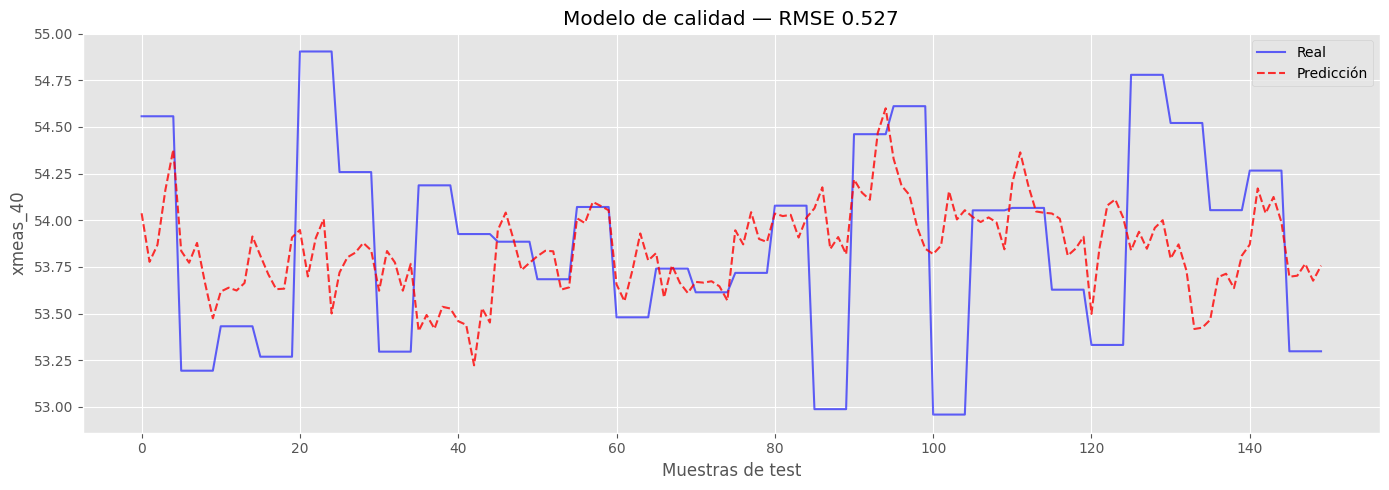

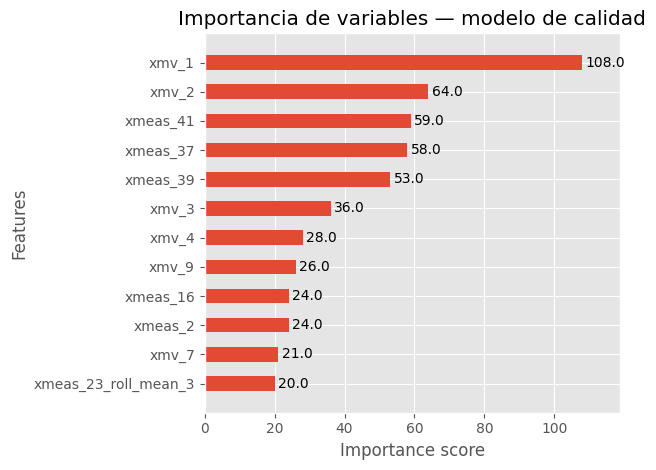

In [97]:
plt.figure(figsize=(14, 5))
plt.plot(res_calidad['y_test'].values, label='Real', color='blue', alpha=0.6)
plt.plot(res_calidad['preds'], label='Predicción', color='red', linestyle='dashed', alpha=0.8)
plt.title(f"Modelo de calidad — RMSE {res_calidad['rmse']:.3f}")
plt.xlabel('Muestras de test')
plt.ylabel(VARIABLE_CALIDAD)
plt.legend()
plt.tight_layout()
plt.show()

xgb.plot_importance(res_calidad['modelo'], height=0.5, importance_type='weight', max_num_features=12)
plt.title('Importancia de variables — modelo de calidad')
plt.tight_layout()
plt.show()

## 6bis-hiperparámetros. Random search sobre los parámetros de XGBoost

Un grid search sobre "todos los parámetros posibles" no es viable: con 10 parámetros ajustables y solo 5 valores candidatos cada uno, son ~9.8 millones de combinaciones (con validación cruzada, ~49 millones de entrenamientos) -- el mismo problema de dimensionalidad que ya vimos con la rejilla de `recomendar_ajuste`, aplicado aquí al espacio de hiperparámetros en vez de al de variables.

La solución es la misma que aplicamos entonces: **random search** en vez de grid search completo -- muestrea N combinaciones al azar de los 10 parámetros a la vez (no solo 2-3), en vez de probar todas. Con un centenar de muestras suele acercarse mucho al óptimo del grid completo, con una fracción ínfima del coste.

**Validación cruzada temporal, no aleatoria**: como es una serie temporal, se usa `TimeSeriesSplit` -- cada fold de validación queda siempre después de su fold de entrenamiento en el tiempo, nunca mezclado (un k-fold aleatorio estándar filtraría información del futuro al pasado, la misma fuga que evitamos con el split cronológico de `evaluar_modelo`).

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import time

# Espacio de búsqueda: rango razonable para cada parámetro, no valores fijos
espacio_hiperparametros = {
    'n_estimators': (50, 400),
    'max_depth': (2, 8),
    'learning_rate': (0.01, 0.3),
    'min_child_weight': (1, 10),
    'gamma': (0, 5),
    'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
    'reg_alpha': (0, 5),
    'reg_lambda': (0, 5),
}

N_MUESTRAS_BUSQUEDA = 30  # sube esto si tienes tiempo/paciencia; 60 ya cubre bastante espacio
N_FOLDS_CV = 3

rng = np.random.default_rng(42)

def muestrear_combinacion():
    return {
        'n_estimators': int(rng.integers(*espacio_hiperparametros['n_estimators'])),
        'max_depth': int(rng.integers(*espacio_hiperparametros['max_depth'])),
        'learning_rate': float(rng.uniform(*espacio_hiperparametros['learning_rate'])),
        'min_child_weight': int(rng.integers(*espacio_hiperparametros['min_child_weight'])),
        'gamma': float(rng.uniform(*espacio_hiperparametros['gamma'])),
        'subsample': float(rng.uniform(*espacio_hiperparametros['subsample'])),
        'colsample_bytree': float(rng.uniform(*espacio_hiperparametros['colsample_bytree'])),
        'reg_alpha': float(rng.uniform(*espacio_hiperparametros['reg_alpha'])),
        'reg_lambda': float(rng.uniform(*espacio_hiperparametros['reg_lambda'])),
    }

print(f"Espacio de búsqueda: {len(espacio_hiperparametros)} parámetros")
print(f"Muestras a evaluar: {N_MUESTRAS_BUSQUEDA} (random search, no grid completo)")
print(f"Ejemplo de combinación muestreada: {muestrear_combinacion()}")

Espacio de búsqueda: 9 parámetros
Muestras a evaluar: 320 (random search, no grid completo)
Ejemplo de combinación muestreada: {'n_estimators': 81, 'max_depth': 6, 'learning_rate': 0.13727474752809518, 'min_child_weight': 4, 'gamma': 3.4868401452968194, 'subsample': 0.5470886739438248, 'colsample_bytree': 0.987811175818378, 'reg_alpha': 3.805698509951765, 'reg_lambda': 3.930321526384769}


In [93]:
tscv = TimeSeriesSplit(n_splits=N_FOLDS_CV)

resultados_busqueda = []
t0_total = time.time()

for i in range(N_MUESTRAS_BUSQUEDA):
    params = muestrear_combinacion()
    rmses_fold = []
    for train_idx, val_idx in tscv.split(X_calidad):
        X_tr, X_val = X_calidad.iloc[train_idx], X_calidad.iloc[val_idx]
        y_tr, y_val = y_calidad.iloc[train_idx], y_calidad.iloc[val_idx]
        modelo = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
        modelo.fit(X_tr, y_tr)
        preds = modelo.predict(X_val)
        rmses_fold.append(np.sqrt(mean_squared_error(y_val, preds)))
    resultados_busqueda.append({**params, 'rmse_cv_medio': np.mean(rmses_fold), 'rmse_cv_std': np.std(rmses_fold)})

tiempo_busqueda = time.time() - t0_total
df_busqueda = pd.DataFrame(resultados_busqueda).sort_values('rmse_cv_medio')

print(f"Búsqueda completa: {N_MUESTRAS_BUSQUEDA} combinaciones x {N_FOLDS_CV} folds = {N_MUESTRAS_BUSQUEDA*N_FOLDS_CV} entrenamientos en {tiempo_busqueda:.1f}s")
print(f"\nMejor combinación encontrada (rmse_cv_medio={df_busqueda.iloc[0]['rmse_cv_medio']:.4f}):")
df_busqueda.head(5)

Búsqueda completa: 320 combinaciones x 3 folds = 960 entrenamientos en 388.6s

Mejor combinación encontrada (rmse_cv_medio=0.4908):


,n_estimators,max_depth,learning_rate,min_child_weight,gamma,subsample,colsample_bytree,reg_alpha,reg_lambda,rmse_cv_medio,rmse_cv_std
198,214,6,0.1342,8,3.1897,0.9281,0.8155,1.7384,3.3126,0.4908,0.1048
316,156,5,0.2112,2,4.2383,0.6188,0.5753,0.0431,0.2363,0.4947,0.1032
114,357,7,0.0403,6,4.5199,0.9328,0.8990,0.4993,1.0220,0.4951,0.1052
46,138,2,0.1451,6,2.6132,0.8820,0.8996,2.4608,2.9980,0.4954,0.1066
161,96,5,0.1013,5,3.3833,0.5330,0.5005,1.0614,4.4726,0.4955,0.1032


In [91]:
mejores_params = df_busqueda.iloc[0][list(espacio_hiperparametros.keys())].to_dict()
mejores_params['n_estimators'] = int(mejores_params['n_estimators'])
mejores_params['max_depth'] = int(mejores_params['max_depth'])
mejores_params['min_child_weight'] = int(mejores_params['min_child_weight'])

res_calidad_ajustado = evaluar_modelo(X_calidad, y_calidad, **{k: v for k, v in mejores_params.items() if k in ['n_estimators', 'max_depth', 'learning_rate']})
# Reentrenar con TODOS los hiperparámetros encontrados (evaluar_modelo solo expone 3 por defecto)
corte = res_calidad_ajustado['corte']
modelo_final_ajustado = xgb.XGBRegressor(**mejores_params, random_state=42, n_jobs=-1)
modelo_final_ajustado.fit(X_calidad.iloc[:corte], y_calidad.iloc[:corte])
preds_ajustado = modelo_final_ajustado.predict(X_calidad.iloc[corte:])
rmse_test_ajustado = np.sqrt(mean_squared_error(y_calidad.iloc[corte:], preds_ajustado))

print(f"RMSE en el mismo test set, hiperparámetros por DEFECTO (n_estimators=150, max_depth=4): {res_calidad['rmse']:.4f}")
print(f"RMSE en el mismo test set, hiperparámetros AJUSTADOS por random search:                  {rmse_test_ajustado:.4f}")

mejora_pct = (1 - rmse_test_ajustado / res_calidad['rmse']) * 100
if mejora_pct > 5:
    print(f"\nMejora real de {mejora_pct:.1f}% -- vale la pena adoptar estos hiperparámetros.")
elif mejora_pct > 0:
    print(f"\nMejora marginal ({mejora_pct:.1f}%) -- puede no compensar la complejidad añadida frente a los valores por defecto.")
else:
    print(f"\nSin mejora real ({mejora_pct:.1f}%) -- los valores por defecto ya eran razonables para este problema.")

RMSE en el mismo test set, hiperparámetros por DEFECTO (n_estimators=150, max_depth=4): 0.5263
RMSE en el mismo test set, hiperparámetros AJUSTADOS por random search:                  0.5424

Sin mejora real (-3.1%) -- los valores por defecto ya eran razonables para este problema.


## 6.1 Construir features por señal, según la tabla de recomendación (en vez de la misma config para todas)

En vez de aplicar la misma configuración (`n_lags`, rolling, diff) a todas las señales de golpe (que es lo que hace `construir_features` cuando le pasas una lista completa de variables), `construir_features_por_señal` llama a `construir_features` **una vez por señal**, con la configuración que le corresponda según `df_recomendacion_features` -- reutilizando la función ya existente, no reescribiendo la lógica de lags/rolling/diff.

In [ ]:
def construir_features_por_señal(df, df_recomendacion, columna_señal='señal',
                                   n_lags_default=5, ventana_default=5):
    """
    Aplica construir_features() UNA VEZ POR SEÑAL, con la configuración que le
    corresponda según su fila en df_recomendacion (columnas 'usar_lags', 'usar_rolling_diff',
    'relevante_para_objetivo') -- en vez de la misma configuración para todas las señales.

    Señales marcadas como no relevantes para el objetivo se excluyen por completo
    (ni siquiera se incluyen como variable original, no solo sin features derivadas).

    Devuelve: (df_con_features, lista_de_columnas_de_features)
    """
    df_out = df.copy()
    columnas_totales = []
    partes_nuevas = []

    for _, fila in df_recomendacion.iterrows():
        var = fila[columna_señal]
        if var == VARIABLE_CALIDAD:
            continue  # no se construyen features de la variable objetivo
        if var not in df.columns:
            continue
        if not fila['relevante_para_objetivo']:
            continue  # se excluye la señal por completo, ni siquiera como variable cruda

        df_var, cols_var = construir_features(
            df, [var],
            usar_lags=bool(fila['usar_lags']), n_lags=n_lags_default,
            usar_rolling_mean=bool(fila['usar_rolling_diff']), ventana_mean=ventana_default,
            usar_rolling_std=False,
            usar_diff=bool(fila['usar_rolling_diff'])
        )
        cols_nuevas_var = [c for c in cols_var if c not in df_out.columns]
        partes_nuevas.append(df_var[cols_nuevas_var])
        columnas_totales.extend([var] + cols_nuevas_var)

    if partes_nuevas:
        df_out = pd.concat([df_out] + partes_nuevas, axis=1)

    columnas_totales = sorted(set(columnas_totales), key=columnas_totales.index)
    return df_out, columnas_totales

In [ ]:
# Demo: aplicar la configuración específica por señal, en vez de la misma para todas
df_feat_guiado, cols_feat_guiado = construir_features_por_señal(
    df_sim, df_recomendacion_features, n_lags_default=1, ventana_default=1
)

print(cols_feat_guiado[:15])

df_feat_guiado[VARIABLE_CALIDAD] = df_sim[VARIABLE_CALIDAD].values
df_feat_guiado[f"{VARIABLE_CALIDAD}_lag1"] = df_sim[VARIABLE_CALIDAD].shift(1).values
cols_feat_guiado.append(f"{VARIABLE_CALIDAD}_lag1")
df_feat_guiado = df_feat_guiado.dropna().reset_index(drop=True)

print(f"Columnas con la configuración global (variables_entrada_calidad, todas iguales): compara con cols_feat de la sección 6")
print(f"Columnas con la configuración guiada por señal: {len(cols_feat_guiado)}")
print(f"\nEjemplo de columnas generadas (primeras 15): {cols_feat_guiado[:15]}")

X_guiado = df_feat_guiado[cols_feat_guiado]
y_guiado = df_feat_guiado[VARIABLE_CALIDAD]
res_guiado = evaluar_modelo(X_guiado, y_guiado, n_estimators=100, max_depth=3)
print(f"\nRMSE con configuración guiada por señal: {res_guiado['rmse']:.4f}")
print(f"Para comparar -- RMSE con configuración global (sección 6): {res_calidad['rmse']:.4f}")

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(res_guiado['y_test'].values, label='Real', color='blue', alpha=0.6)
plt.plot(res_guiado['preds'], label='Predicción', color='red', linestyle='dashed', alpha=0.8)
plt.title(f"Modelo de calidad — RMSE {res_guiado['rmse']:.3f}")
plt.xlabel('Muestras de test')
plt.ylabel(VARIABLE_CALIDAD)
plt.legend()
plt.tight_layout()
plt.show()

xgb.plot_importance(res_guiado['modelo'], height=0.5, importance_type='weight', max_num_features=12)
plt.title('Importancia de variables — modelo de calidad')
plt.tight_layout()
plt.show()

### ¿El modelo de nowcast mejora sobre no hacer nada? -- baseline naive

Mismo criterio que ya aplicamos en forecasting (sección 7): un RMSE bajo en términos absolutos no dice si el modelo aporta algo real. Aquí el baseline naive es distinto al de forecasting -- en nowcast no hay un "valor en t" separado del target (el target ES el valor en t), así que el naive tiene que ser el último valor **conocido antes** de ese instante: predecir que `calidad(t) = calidad(t-1)`.

Esto es especialmente relevante ahora mismo porque el modelo de nowcast está configurado con `usar_lags=False` -- es decir, no tiene acceso directo al pasado de la propia variable de calidad como feature. Si el naive (que sí usa ese pasado, aunque de forma trivial) le gana o se le acerca mucho, es una señal clara de que activar lags podría ayudar.

In [ ]:
rmse_naive_nowcast = np.sqrt(mean_squared_error(
    res_calidad['y_test'],
    df_feat['calidad_lag1_naive'].iloc[res_calidad['corte']:].reset_index(drop=True)
))
rmse_modelo_nowcast = res_calidad['rmse']

print(f"RMSE del modelo XGBoost (nowcast):        {rmse_modelo_nowcast:.4f}")
print(f"RMSE del baseline naive (calidad(t-1)):   {rmse_naive_nowcast:.4f}")

mejora_pct_nowcast = (1 - rmse_modelo_nowcast / rmse_naive_nowcast) * 100
print(f"\nMejora del modelo sobre el baseline naive: {mejora_pct_nowcast:+.1f}%")

if mejora_pct_nowcast < 5:
    print("ALERTA: El modelo apenas mejora sobre \"calidad(t) = calidad(t-1)\" -- con usar_lags=False")
    print("    el modelo no tiene acceso directo a ese valor tan informativo. Prueba a activar")
    print("    usar_lags=True con pocos lags (el PACF de la sección 4 te dice cuántos tienen sentido)")
    print("    antes de concluir que las XMV/XMEAS no aportan nada.")
elif mejora_pct_nowcast < 20:
    print("El modelo mejora sobre el baseline, pero de forma modesta.")
else:
    print("El modelo mejora claramente sobre el baseline naive -- señal de que las XMV/XMEAS")
    print("  aportan información real más allá de la inercia de la propia variable.")

## 6bis-residuo. Modelo alternativo: predecir el residuo frente al naive

En vez de predecir `VARIABLE_CALIDAD` directamente (con `calidad_lag1_naive` compitiendo como una feature más -- y potencialmente dominando, como vimos con datos de inercia fuerte), aquí se predice el **residuo**: `VARIABLE_CALIDAD - calidad_lag1_naive`. El lag ya no es un input -- es la referencia que se resta *antes* de entrenar, no una columna que compite dentro del modelo.

Esto no es "otro modelo entrenado sobre la salida de un modelo" (eso sería stacking, con su propio riesgo de fuga de información si no se separan bien los datos) -- es una resta aritmética contra el propio valor anterior de la señal, sin ningún entrenamiento de por medio. Cero riesgo de fuga adicional.

**Importante para `recomendar_ajuste`**: este modelo predice el residuo, no la calidad directamente. Para usarlo en la búsqueda de recomendación hay que reconstruir: `calidad_predicha = calidad_lag1_naive + residuo_predicho`. Se deja preparado más abajo, pero no se sustituye `res_calidad` por defecto -- queda como alternativa a comparar, no como reemplazo automático.

In [ ]:
cols_feat_sin_lag = [c for c in cols_feat if c != 'calidad_lag1_naive']

y_residuo = df_feat[VARIABLE_CALIDAD] - df_feat['calidad_lag1_naive']
X_residuo = df_feat[cols_feat_sin_lag]

res_residuo = evaluar_modelo(X_residuo, y_residuo, n_estimators=150, max_depth=4)
print(f"RMSE prediciendo el RESIDUO: {res_residuo['rmse']:.4f}")

# Reconstruir la predicción de calidad real, para comparar en las mismas unidades que res_calidad
corte = res_residuo['corte']
calidad_lag1_test = df_feat['calidad_lag1_naive'].iloc[corte:].reset_index(drop=True)
calidad_real_test = df_feat[VARIABLE_CALIDAD].iloc[corte:].reset_index(drop=True)
calidad_predicha_reconstruida = calidad_lag1_test + res_residuo['preds']

rmse_reconstruido = np.sqrt(mean_squared_error(calidad_real_test, calidad_predicha_reconstruida))

print(f"\nRMSE modelo directo (calidad, con lag como feature):     {res_calidad['rmse']:.4f}")
print(f"RMSE modelo de residuo (reconstruido a unidades de calidad): {rmse_reconstruido:.4f}")

In [ ]:
imp_directo = res_calidad['modelo'].get_booster().get_score(importance_type='gain')
imp_directo_completa = {c: imp_directo.get(c, 0) for c in cols_feat}
total_directo = sum(imp_directo_completa.values())

imp_residuo = res_residuo['modelo'].get_booster().get_score(importance_type='gain')
imp_residuo_completa = {c: imp_residuo.get(c, 0) for c in cols_feat_sin_lag}
total_residuo = sum(imp_residuo_completa.values())

print("Importancia (gain %) -- modelo DIRECTO (lag compite con el resto):")
for c, v in sorted(imp_directo_completa.items(), key=lambda x: -x[1])[:8]:
    print(f"  {c:30s}: {100*v/total_directo:.1f}%" if total_directo > 0 else f"  {c}: 0%")

print("\nImportancia (gain %) -- modelo de RESIDUO (sin el lag como candidato):")
for c, v in sorted(imp_residuo_completa.items(), key=lambda x: -x[1])[:8]:
    print(f"  {c:30s}: {100*v/total_residuo:.1f}%" if total_residuo > 0 else f"  {c}: 0%")

print("\nSi en el modelo directo una sola variable (probablemente el lag) domina con >80-90%,")
print("y en el modelo de residuo la importancia se reparte más entre las XMV,")
print("el modelo de residuo es la mejor base para recomendar_ajuste -- tiene sensibilidad")
print("real a las variables que se pueden ajustar, en vez de depender casi todo de la inercia.")

## 6ter. Filtrar variables por importancia del propio modelo

Usar la importancia de un XGBoost ya entrenado como criterio de selección de variables (lo que hacen varios papers de este estilo) es razonable, pero tiene tres matices que hay que resolver bien o el filtro puede engañarte:

1. **La importancia no es una propiedad fija de cada señal, depende de qué más metiste.** Con señales redundantes, el árbol reparte (a veces de forma inconsistente) la importancia entre ambas -- por eso este filtro se hace *después* de resolver la redundancia (sección 3, `redundant_pairs`), no antes.
2. **Circularidad si decides el filtro mirando el test.** La importancia se calcula sobre train; el filtro se decide sin haber mirado aún el RMSE de test. Solo después evaluamos el modelo filtrado en test, para que la comparación sea honesta y no un ajuste al ruido de ese test concreto.
3. **Usamos `gain`, no `weight`** (la razón ya la vimos: `weight` cuenta veces-usada, `gain` cuenta cuánto reduce el error -- son cosas distintas y `gain` es la que responde a "cuánto aporta de verdad").

Además, repetimos el cálculo con varias semillas -- si el conjunto de variables "importantes" cambia mucho de una semilla a otra, no es una conclusión robusta sobre el proceso, es ruido de una ejecución concreta (el mismo principio que ya aplicamos para el mejor lag entre simulaciones, sección 3).

In [ ]:
# Paso 1: modelo completo con TODAS las variables candidatas, importancia calculada
# SOLO sobre train -- no miramos el test todavía, para no contaminar la decisión del filtro
X_completo = df_feat[cols_feat]
y_completo = df_feat[VARIABLE_CALIDAD]
corte_completo = res_calidad['corte']

Xtr_completo = X_completo.iloc[:corte_completo]
ytr_completo = y_completo.iloc[:corte_completo]

modelo_completo_imp = xgb.XGBRegressor(n_estimators=150, max_depth=4, random_state=42, n_jobs=-1)
modelo_completo_imp.fit(Xtr_completo, ytr_completo)

imp_gain_dict = modelo_completo_imp.get_booster().get_score(importance_type='gain')
# Variables que nunca se usaron en ningún split no aparecen en el dict -- importancia 0, no ausente
importancia_gain = pd.Series({c: imp_gain_dict.get(c, 0.0) for c in cols_feat}).sort_values(ascending=False)

print("Top 15 variables por gain (calculado solo sobre train):")
importancia_gain.head(15)

In [ ]:
# Paso 2: filtro -- top-N por gain, decidido SOLO con la importancia de train
N_TOP_FEATURES = 10

variables_filtradas = importancia_gain.head(N_TOP_FEATURES).index.tolist()
print(f"Variables filtradas (top {N_TOP_FEATURES} por gain): {variables_filtradas}")

# Paso 3: AHORA sí, reentrenar con el subconjunto y comparar en test -- esta es la
# única comparación que decide si el filtro fue una buena idea o no
X_filtrado = df_feat[variables_filtradas]
res_filtrado = evaluar_modelo(X_filtrado, y_completo, n_estimators=150, max_depth=4)

rmse_completo_test = np.sqrt(mean_squared_error(
    y_completo.iloc[corte_completo:], modelo_completo_imp.predict(X_completo.iloc[corte_completo:])
))

print(f"\nRMSE modelo COMPLETO  ({len(cols_feat)} variables): {rmse_completo_test:.4f}")
print(f"RMSE modelo FILTRADO  ({N_TOP_FEATURES} variables):  {res_filtrado['rmse']:.4f}")

diferencia_pct = (res_filtrado['rmse'] / rmse_completo_test - 1) * 100
if diferencia_pct < 5:
    print(f"\nEl filtro apenas empeora el RMSE ({diferencia_pct:+.1f}%) con muchas menos variables --")
    print("    buena señal: el resto de columnas aportaban poco o nada, y el modelo filtrado")
    print("    es más simple e interpretable sin sacrificar precisión.")
else:
    print(f"\nEl filtro empeora el RMSE notablemente ({diferencia_pct:+.1f}%) -- probablemente quitaste")
    print("    alguna variable que aportaba por interacción con otras, no de forma marginal.")
    print("    Prueba a subir N_TOP_FEATURES antes de dar el filtro por bueno.")

In [ ]:
# Paso 4: repetir con varias semillas -- ¿el conjunto de variables "importantes" es
# estable, o cambia según el azar del entrenamiento? Si cambia mucho, no es una
# conclusión robusta sobre el proceso -- es ruido de una ejecución concreta.
N_SEMILLAS = 5
apariciones_top = {c: 0 for c in cols_feat}

for seed in range(N_SEMILLAS):
    m_seed = xgb.XGBRegressor(n_estimators=150, max_depth=4, random_state=seed, n_jobs=-1)
    m_seed.fit(Xtr_completo, ytr_completo)
    imp_seed = m_seed.get_booster().get_score(importance_type='gain')
    imp_seed_completa = pd.Series({c: imp_seed.get(c, 0.0) for c in cols_feat}).sort_values(ascending=False)
    for c in imp_seed_completa.head(N_TOP_FEATURES).index:
        apariciones_top[c] += 1

df_estabilidad_imp = pd.Series(apariciones_top).sort_values(ascending=False)
df_estabilidad_imp = df_estabilidad_imp[df_estabilidad_imp > 0]

print(f"Nº de veces (de {N_SEMILLAS} semillas) que cada variable aparece en el top-{N_TOP_FEATURES}:")
print(df_estabilidad_imp)
print(f"\nVariables presentes en TODAS las semillas ({N_SEMILLAS}/{N_SEMILLAS}): candidatas robustas al filtro")
print(f"Variables presentes en pocas semillas: su importancia puede ser ruido de una ejecución concreta")

### ¿Sustituir cada XMEAS del filtro por "su" XMV? -- comprobarlo antes de asumirlo

Si el filtro por importancia (arriba) deja XMEAS en el top-N, la tentación es sustituir cada una por la XMV que más la controla, para que `recomendar_ajuste` tenga más margen de acción. Antes de hacerlo, hay que comprobar si existe **una** XMV dominante para cada XMEAS, o si la señal agrega el efecto de **varias** XMV a la vez -- son dos situaciones distintas con soluciones distintas:

- **Una XMV dominante**: sustituir tiene sentido, no se pierde apenas información.
- **Varias XMV con peso repartido**: sustituir por una sola pierde información real que las otras aportaban. Aquí la solución no es sustituir, es **añadir el grupo completo de XMV correlacionadas** como candidatas adicionales para la búsqueda de recomendación -- sin quitar la XMEAS, que sigue siendo la mejor fuente de precisión para el modelo predictivo.

In [ ]:
UMBRAL_CORR_GRUPO = 0.6  # por debajo de esto, no consideramos que la XMV explique la XMEAS

# Tomamos las XMEAS que quedaron en el filtro de importancia (variables_filtradas, sección 6ter)
xmeas_en_filtro = [v for v in variables_filtradas if v in VARIABLES_XMEAS]

grupos_xmv_por_xmeas = {}
for xmeas_var in xmeas_en_filtro:
    correlaciones = {}
    for xmv_var in VARIABLES_XMV:
        perfil = perfil_correlacion_cruzada(df_sim[xmv_var], df_sim[xmeas_var], max_lag=MAX_LAG_CUBO)
        mejor = max(perfil.values(), key=abs)
        correlaciones[xmv_var] = mejor
    serie_corr = pd.Series(correlaciones).sort_values(key=abs, ascending=False)

    xmv_relevantes = serie_corr[serie_corr.abs() > UMBRAL_CORR_GRUPO].index.tolist()
    grupos_xmv_por_xmeas[xmeas_var] = xmv_relevantes

    dominante = abs(serie_corr.iloc[0])
    segunda = abs(serie_corr.iloc[1]) if len(serie_corr) > 1 else 0
    tipo = "UNA XMV dominante" if (dominante > 0.6 and dominante > 2*segunda) else "VARIAS XMV con peso repartido"
    print(f"{xmeas_var}: {tipo} -- {len(xmv_relevantes)} XMV por encima de |r|={UMBRAL_CORR_GRUPO}: {xmv_relevantes}")

# Unión de todas las XMV relevantes para las XMEAS del filtro -- candidatas a asegurar
# que estén disponibles en recomendar_ajuste, sin necesidad de quitar las XMEAS del modelo
xmv_grupo_completo = sorted(set(v for grupo in grupos_xmv_por_xmeas.values() for v in grupo))
print(f"\nUnión de XMV relevantes para las XMEAS del filtro: {xmv_grupo_completo}")
print(f"({len(xmv_grupo_completo)} de {len(VARIABLES_XMV)} XMV totales)")

## 6bis. Entrenar con más simulaciones (400 train / 100 test) -- hecho bien, no solo "más filas"

Con 500 simulaciones disponibles, usar más de una para entrenar es razonable -- un modelo entrenado sobre una sola simulación (`simulationRun == 1`) solo ha visto una "historia" del proceso, y no sabes si generaliza a las otras 499.

**Pero hay una decisión de diseño que hay que tomar con cuidado, no dar por hecha:** ¿qué significa "train" y "test" cuando la unidad natural no es una fila, es una simulación completa?

- **Split por simulación completa (lo correcto aquí):** 400 simulaciones enteras para entrenar, 100 simulaciones enteras -- nunca vistas, ni una fila -- para test. El modelo se evalúa en "historias" del proceso que no vio en absoluto.
- **Concatenar las 500 simulaciones en una serie larga y partir cronológicamente (lo que haría el código actual sin cambios):** esto es un error, no una simplificación aceptable. `construir_features` usa `shift()`/`rolling()`, que al concatenar simulaciones distintas calcularía lags falsos en cada una de las 499 costuras -- la primera fila de la simulación 37 tomaría como "lag 1" la última fila de la simulación 36, que es un experimento completamente distinto sin continuidad temporal real.

La solución: calcular las features **por separado dentro de cada simulación** (para que ningún lag cruce la frontera entre experimentos) y solo después concatenar y hacer el split por simulación completa.

Sobre el tiempo: entrenar con ~200.000 filas y ~50 features no es lento (segundos, no minutos) -- XGBoost escala bien en el número de filas. Lo que sí hay que hacer con cuidado es el cálculo de features (una llamada a `construir_features` por cada una de las 500 simulaciones), que este notebook resuelve con un bucle simple, no con algo costoso.

In [ ]:
def construir_features_multi_sim(df_raw, columna_sim, variables_entrada, columna_objetivo=None,
                                   **kwargs_features):
    """
    Aplica construir_features() de forma INDEPENDIENTE a cada simulación (evita que los
    lags/rolling/diff crucen la frontera entre simulaciones distintas) y concatena el resultado.

    Si se pasa columna_objetivo, se añade DENTRO del bucle por cada grupo -- así queda
    perfectamente alineada con el resto de columnas sin depender de reconstruir índices
    después de concatenar (que es donde es fácil desalinearse sin que salte ningún error).
    """
    partes = []
    columnas_features = None
    for sim_id, grupo in df_raw.groupby(columna_sim):
        grupo = grupo.sort_values(COLUMNA_TIEMPO).reset_index(drop=True)
        df_feat_sim, cols = construir_features(grupo, variables_entrada, **kwargs_features)
        if columna_objetivo is not None:
            df_feat_sim[columna_objetivo] = grupo[columna_objetivo].values
            # Baseline naive para nowcast: calidad(t-1), calculado DENTRO de cada simulación
            # -- igual que el target, si se calculara sobre el concatenado, la primera fila
            # de cada simulación tomaría como "naive" el último valor de la simulación anterior.
            df_feat_sim[f'{columna_objetivo}_lag1_naive'] = grupo[columna_objetivo].shift(1).values
        df_feat_sim[columna_sim] = sim_id
        partes.append(df_feat_sim)
        columnas_features = cols
    df_concat = pd.concat(partes, ignore_index=True)
    return df_concat, columnas_features


def evaluar_modelo_split_por_simulacion(df_feat, cols_feat, columna_objetivo, columna_sim,
                                          simulaciones_train, simulaciones_test,
                                          n_estimators=150, max_depth=3, learning_rate=0.1):
    """
    Igual que evaluar_modelo(), pero el split es por SIMULACIÓN COMPLETA, no cronológico
    sobre una serie concatenada -- el test usa simulaciones que el modelo no vio ni una fila.
    """
    df_train = df_feat[df_feat[columna_sim].isin(simulaciones_train)]
    df_test = df_feat[df_feat[columna_sim].isin(simulaciones_test)]

    X_train, y_train = df_train[cols_feat], df_train[columna_objetivo]
    X_test, y_test = df_test[cols_feat], df_test[columna_objetivo]

    modelo = xgb.XGBRegressor(
        n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate,
        random_state=42, n_jobs=-1
    )
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return {"modelo": modelo, "rmse": rmse, "X_test": X_test, "y_test": y_test, "preds": preds}

In [ ]:
import time

# simulaciones_train / simulaciones_test vienen de la configuración cargada arriba
# (decididas una sola vez en 01_diagnostico.ipynb, para que 02 y 03 usen el mismo split)
simulaciones_train = configuracion['simulaciones_train']
simulaciones_test = configuracion['simulaciones_test']

t0 = time.time()
df_feat_multi, cols_feat_multi = construir_features_multi_sim(
    df_raw, 'simulationRun', variables_entrada_calidad, columna_objetivo=VARIABLE_CALIDAD,
    usar_lags=True, n_lags=5, espaciado_lags='consecutivo',
    usar_rolling_mean=True, ventana_mean=5,
    usar_rolling_std=False,
    usar_diff=True
)
df_feat_multi = df_feat_multi.dropna().reset_index(drop=True)
t1 = time.time()
tiempo_features = t1 - t0
print(f"Features calculadas por simulación (500 simulaciones), tiempo: {tiempo_features:.2f}s")
print(f"Filas totales tras construir features y dropna: {len(df_feat_multi)}")

t0 = time.time()
res_multi_sim = evaluar_modelo_split_por_simulacion(
    df_feat_multi, cols_feat_multi, VARIABLE_CALIDAD, 'simulationRun',
    simulaciones_train, simulaciones_test,
    n_estimators=100, max_depth=4
)
t1 = time.time()
tiempo_entrenamiento = t1 - t0

rmse_multi = res_multi_sim['rmse']
rmse_una_sim = res_calidad['rmse']

print(f"\nEntrenamiento ({len(simulaciones_train)} simulaciones) + evaluación ({len(simulaciones_test)} simulaciones): {tiempo_entrenamiento:.2f}s")
print(f"RMSE con split por simulación completa: {rmse_multi:.4f}")
print(f"Para comparar -- RMSE con solo simulationRun==1: {rmse_una_sim:.4f}")

### Baseline naive, ahora con el split robusto (400/100 simulaciones)

El baseline naive anterior se calculó sobre una sola simulación -- optimista, igual que el modelo. Aquí lo repetimos con el mismo split por simulación completa, para que la comparación modelo-vs-naive sea tan fiable como el propio RMSE del modelo.

In [ ]:
col_naive = f'{VARIABLE_CALIDAD}_lag1_naive'
naive_test = df_feat_multi.loc[res_multi_sim['X_test'].index, col_naive]

rmse_naive_multi = np.sqrt(mean_squared_error(res_multi_sim['y_test'], naive_test))
rmse_modelo_multi = res_multi_sim['rmse']

print(f"RMSE del modelo XGBoost (nowcast, 400/100 simulaciones):  {rmse_modelo_multi:.4f}")
print(f"RMSE del baseline naive (calidad(t-1)):                    {rmse_naive_multi:.4f}")

mejora_pct_multi = (1 - rmse_modelo_multi / rmse_naive_multi) * 100
print(f"\nMejora del modelo sobre el baseline naive: {mejora_pct_multi:+.1f}%")

if mejora_pct_multi < 5:
    print("ALERTA: incluso con 400 simulaciones de entrenamiento, el modelo apenas mejora sobre")
    print("    \"no va a cambiar nada\". Esto ya no se explica por sobreajuste a una sola simulación")
    print("    -- si persiste aquí, es una señal real de que las XMV/XMEAS actuales no aportan mucho")
    print("    más que la propia inercia de la variable en este horizonte.")
elif mejora_pct_multi < 20:
    print("El modelo mejora sobre el baseline, pero de forma modesta -- con el split robusto,")
    print("    esta cifra es más fiable que la de una sola simulación.")
else:
    print("El modelo mejora claramente sobre el baseline naive, incluso con el split robusto de")
    print("    400/100 simulaciones -- buena señal de que está aprendiendo relaciones reales.")

## Guardar artefactos para el notebook de recomendación

Guardamos el modelo entrenado (el de una simulación y, si lo ejecutaste, el de 400/100) y los datos de features, para que `04_recomendacion.ipynb` pueda usarlos sin reentrenar.

In [ ]:
import joblib

joblib.dump(res_calidad['modelo'], '../artefactos/modelo_nowcast_una_sim.joblib')
df_feat.to_csv('../artefactos/df_feat_nowcast.csv', index=False)
with open('../artefactos/cols_feat_nowcast.pkl', 'wb') as f:
    pickle.dump(cols_feat, f)
with open('../artefactos/rmse_nowcast.pkl', 'wb') as f:
    pickle.dump({'rmse_una_sim': res_calidad['rmse']}, f)

if 'res_multi_sim' in dir():
    joblib.dump(res_multi_sim['modelo'], '../artefactos/modelo_nowcast_multi_sim.joblib')
    df_feat_multi.to_csv('../artefactos/df_feat_nowcast_multi.csv', index=False)
    with open('../artefactos/cols_feat_nowcast_multi.pkl', 'wb') as f:
        pickle.dump(cols_feat_multi, f)
    print("Guardado: modelo_nowcast_una_sim.joblib + modelo_nowcast_multi_sim.joblib (y sus df_feat)")
else:
    print("Guardado: modelo_nowcast_una_sim.joblib (df_feat)")
    print("(No se ejecutó la sección 6bis en esta sesión -- si la necesitas, ejecútala antes de esta celda)")